In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(
"/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/ALIGNBREAKPOINTS/FULL_hyper_blast_bestlen_summary.tsv",
sep="\t"
)

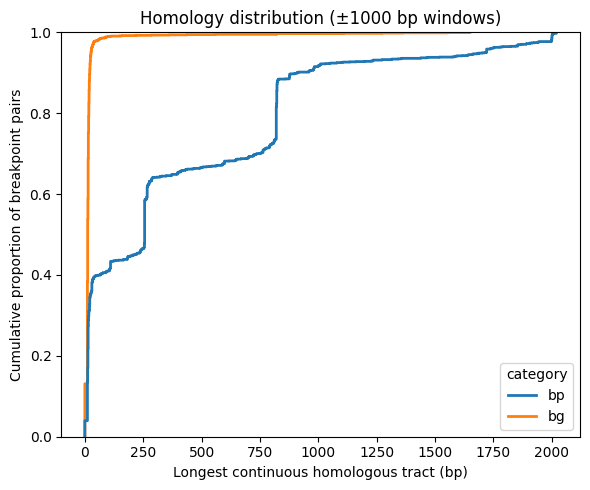

In [3]:
hw = 1000

sub = df[df["window_hw"] == hw].copy()

plt.figure(figsize=(6,5))

sns.ecdfplot(
    data=sub,
    x="best_len",
    hue="category",
    linewidth=2
)

plt.xlabel("Longest continuous homologous tract (bp)")
plt.ylabel("Cumulative proportion of breakpoint pairs")
plt.title(f"Homology distribution (±{hw} bp windows)")
plt.tight_layout()
plt.show()

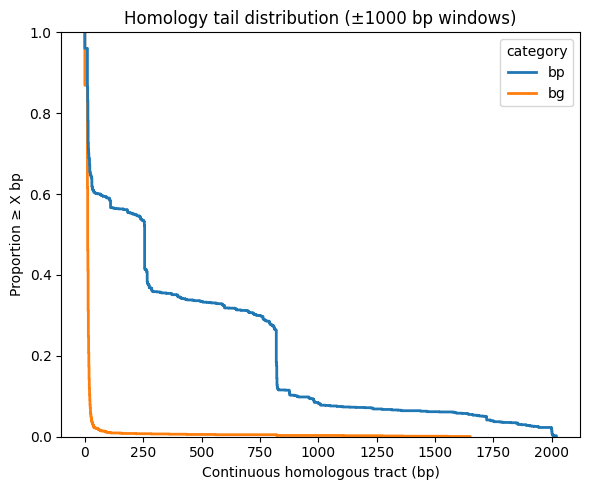

In [4]:
plt.figure(figsize=(6,5))

sns.ecdfplot(
    data=sub,
    x="best_len",
    hue="category",
    complementary=True,
    linewidth=2
)

plt.xlabel("Continuous homologous tract (bp)")
plt.ylabel("Proportion ≥ X bp")
plt.title(f"Homology tail distribution (±{hw} bp windows)")
plt.tight_layout()
plt.show()

In [7]:
import os
import re
import csv
import pandas as pd

# ============================================================
# INPUTS
# ============================================================

BASE_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
NUCMER_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/containment_mm2/nucmer"
GRAPH_DIR = os.path.join(NUCMER_DIR, "graph_cov90_noclose")
CONTAINMENT_FILE = os.path.join(GRAPH_DIR, "containment_NUC_levelup_strictlen.tsv")

CLUSTER_FILE = os.path.join(BASE_DIR, "ALIGNBREAKPOINTS", "hspq_clusters_cluster.tsv")
PAIR_INDEX_FILE = os.path.join(BASE_DIR, "ALIGNBREAKPOINTS", "FULL_hyper_blast_pair_index.tsv")
REPLICONS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/plasmid_replicons.tsv"

TOP_N = 3

# ============================================================
# HELPERS
# ============================================================

def parse_cov90_line(line):
    toks = re.split(r"\s+", line.strip())
    if len(toks) < 14:
        return None
    try:
        return {
            "s1": int(toks[0]),
            "e1": int(toks[1]),
            "s2": int(toks[2]),
            "e2": int(toks[3]),
            "lenR": int(toks[7]),
            "lenQ": int(toks[8]),
            "ref": toks[11],
            "qry": toks[12],
        }
    except Exception:
        return None

def get_cov90_path(src):
    p = os.path.join(NUCMER_DIR, src)
    if os.path.exists(p):
        return p
    p = os.path.join(GRAPH_DIR, os.path.basename(src))
    if os.path.exists(p):
        return p
    raise FileNotFoundError(f"No encuentro cov90 para: {src}")

def extract_pair_id(x):
    m = re.match(r"pair(\d+)", str(x))
    return int(m.group(1)) if m else None

def extract_bp_index_from_path(x):
    m = re.search(r"bp_(\d+)\.fa$", str(x))
    return int(m.group(1)) if m else None

# ============================================================
# 1. RECONSTRUIR bp_index -> plasmid
# ============================================================

breakpoints = []

with open(CONTAINMENT_FILE) as f:
    rdr = csv.DictReader(f, delimiter="\t")
    for row in rdr:
        big_len = int(row["big_len"])
        cov_path = get_cov90_path(row["source_file"])

        with open(cov_path) as fh:
            found = False
            for line in fh:
                parsed = parse_cov90_line(line)
                if not parsed:
                    continue

                if parsed["lenR"] == big_len:
                    chrom = parsed["ref"]
                    s = min(parsed["s1"], parsed["e1"])
                    e = max(parsed["s1"], parsed["e1"])
                elif parsed["lenQ"] == big_len:
                    chrom = parsed["qry"]
                    s = min(parsed["s2"], parsed["e2"])
                    e = max(parsed["s2"], parsed["e2"])
                else:
                    continue

                breakpoints.append({
                    "bp_index": len(breakpoints),
                    "plasmid": chrom
                })
                breakpoints.append({
                    "bp_index": len(breakpoints),
                    "plasmid": chrom
                })
                found = True
                break

        if not found:
            print(f"[WARN] No se encontró línea válida en {cov_path}")

bp_df = pd.DataFrame(breakpoints)

# ============================================================
# 2. pair_id -> plasmid multireplicon
# ============================================================

pair_idx = pd.read_csv(PAIR_INDEX_FILE, sep="\t")
pair_idx = pair_idx[pair_idx["category"] == "bp"].copy()

pair_idx["bp1_index"] = pair_idx["fa1"].apply(extract_bp_index_from_path)
pair_idx["bp2_index"] = pair_idx["fa2"].apply(extract_bp_index_from_path)

pair_to_bp = pair_idx[["pair_id", "bp1_index", "bp2_index"]].copy()

pair_to_bp = pair_to_bp.merge(
    bp_df.add_prefix("bp1_"),
    left_on="bp1_index",
    right_on="bp1_bp_index",
    how="left"
)

pair_to_bp = pair_to_bp.merge(
    bp_df.add_prefix("bp2_"),
    left_on="bp2_index",
    right_on="bp2_bp_index",
    how="left"
)

pair_to_bp["plasmid"] = pair_to_bp["bp1_plasmid"]

# ============================================================
# 3. TOP CLUSTERS
# ============================================================

cl = pd.read_csv(CLUSTER_FILE, sep="\t", header=None, names=["rep", "member"])

cluster_sizes = (
    cl.groupby("rep")
      .size()
      .sort_values(ascending=False)
      .reset_index(name="n_members")
)

top_clusters = cluster_sizes.head(TOP_N)["rep"].tolist()

cl_top = cl[cl["rep"].isin(top_clusters)].copy()
cl_top["pair_id"] = cl_top["member"].apply(extract_pair_id)
cl_top = cl_top.dropna(subset=["pair_id"]).copy()
cl_top["pair_id"] = cl_top["pair_id"].astype(int)

# ============================================================
# 4. cluster -> plasmid multireplicon
# ============================================================

cluster_pairs = cl_top.merge(
    pair_to_bp[["pair_id", "plasmid"]],
    on="pair_id",
    how="left"
)

cluster_plasmids = (
    cluster_pairs[["rep", "plasmid"]]
    .dropna()
    .drop_duplicates()
    .rename(columns={"rep": "cluster"})
)

# ============================================================
# 5. CARGAR TABLA DE REPLICONES
# ============================================================

rep = pd.read_csv(REPLICONS_FILE, sep="\t")

plasmid_col = None
replicon_col = None

for c in rep.columns:
    lc = c.lower()
    if plasmid_col is None and ("plasmid" in lc or c == "NUCCORE_ACC"):
        plasmid_col = c
    if replicon_col is None and ("rep_type" in lc or "replicon" in lc):
        replicon_col = c

if plasmid_col is None or replicon_col is None:
    raise ValueError(
        f"No pude detectar columnas de plasmid/replicons en {REPLICONS_FILE}. "
        f"Columnas: {list(rep.columns)}"
    )

rep = rep.rename(columns={
    plasmid_col: "plasmid",
    replicon_col: "replicons"
})

rep["plasmid"] = rep["plasmid"].astype(str).str.strip()
rep["replicons"] = rep["replicons"].fillna("").astype(str)

# ============================================================
# 6. TABLA FINAL: cluster | plasmid | replicons completos
# ============================================================

final = cluster_plasmids.merge(
    rep[["plasmid", "replicons"]].drop_duplicates(),
    on="plasmid",
    how="left"
)

final = final.sort_values(["cluster", "plasmid"]).reset_index(drop=True)

print("\n=== PLASMIDOS MULTIREPLICON Y SU LISTA COMPLETA DE REPLICONES ===")
print(final.head(50))

# opcional: guardar
# final.to_csv("top3_clusters_multireplicon_plasmids_and_full_replicons.tsv", sep="\t", index=False)


=== PLASMIDOS MULTIREPLICON Y SU LISTA COMPLETA DE REPLICONES ===
                                              cluster        plasmid  \
0   pair250|len275|pid100.0|q1727-2001|s1-275|side...     CP011314.1   
1   pair250|len275|pid100.0|q1727-2001|s1-275|side...     CP031284.1   
2   pair250|len275|pid100.0|q1727-2001|s1-275|side...     CP035776.1   
3   pair250|len275|pid100.0|q1727-2001|s1-275|side...     CP040445.1   
4   pair250|len275|pid100.0|q1727-2001|s1-275|side...     CP048861.1   
5   pair250|len275|pid100.0|q1727-2001|s1-275|side...     CP056986.1   
6   pair250|len275|pid100.0|q1727-2001|s1-275|side...     CP057840.1   
7   pair250|len275|pid100.0|q1727-2001|s1-275|side...     CP067557.1   
8   pair250|len275|pid100.0|q1727-2001|s1-275|side...     CP088684.1   
9   pair250|len275|pid100.0|q1727-2001|s1-275|side...     CP088861.1   
10  pair250|len275|pid100.0|q1727-2001|s1-275|side...     CP099244.1   
11  pair250|len275|pid100.0|q1727-2001|s1-275|side...     CP119496.1 

In [8]:
import pandas as pd

# Asume que ya tienes `final` del chunk anterior con columnas:
# cluster | plasmid | replicons

# --------------------------------------------------
# 1. LIMPIAR Y EXPLOTAR LISTAS DE REPLICONES
# --------------------------------------------------

tmp = final.copy()

tmp["replicons"] = tmp["replicons"].fillna("").astype(str).str.split(",")
tmp = tmp.explode("replicons")
tmp["replicons"] = tmp["replicons"].str.strip()
tmp = tmp[tmp["replicons"] != ""]

# --------------------------------------------------
# 2. CONTAR COMBINACIONES COMPLETAS DE REPLICONES POR CLUSTER
# --------------------------------------------------

combo_counts = (
    final.copy()
    .assign(replicons=final["replicons"].fillna("").astype(str).str.strip())
    .groupby(["cluster", "replicons"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count", "replicons"], ascending=[True, False, True])
)

print("\n=== COMBINACIONES COMPLETAS DE REPLICONES POR CLUSTER ===")
for cluster, sub in combo_counts.groupby("cluster", sort=False):
    print(f"\n{cluster}")
    for _, row in sub.iterrows():
        print(f"  {row['replicons']} -> {row['count']}")

# --------------------------------------------------
# 3. CONTAR REPLICONES INDIVIDUALES POR CLUSTER
# --------------------------------------------------

rep_counts = (
    tmp.groupby(["cluster", "replicons"])
       .size()
       .reset_index(name="count")
       .sort_values(["cluster", "count", "replicons"], ascending=[True, False, True])
)

print("\n=== REPLICONES INDIVIDUALES POR CLUSTER ===")
for cluster, sub in rep_counts.groupby("cluster", sort=False):
    print(f"\n{cluster}")
    for _, row in sub.iterrows():
        print(f"  {row['replicons']} -> {row['count']}")

# opcional: guardar
# combo_counts.to_csv("top3_clusters_replicon_combinations_counts.tsv", sep="\t", index=False)
# rep_counts.to_csv("top3_clusters_individual_replicon_counts.tsv", sep="\t", index=False)


=== COMBINACIONES COMPLETAS DE REPLICONES POR CLUSTER ===

pair250|len275|pid100.0|q1727-2001|s1-275|side=query
  IncHI2A,IncQ1,rep_cluster_1088 -> 12
  IncFIB,IncFIC,IncQ1,rep_cluster_2244 -> 9
  IncFIB,IncFII,IncQ1 -> 8
  IncFII,IncQ1,rep_cluster_1418,rep_cluster_2183 -> 6
  IncFIA,IncFIB,IncFII,IncQ1 -> 5
  IncFIB,IncFII,IncQ1,rep_cluster_2183 -> 5
  IncFIA,IncFIB,IncFII,IncFII,IncQ1 -> 4
  IncFIA,IncFIB,IncQ1 -> 4
  IncFIA,IncFIB,IncFIC,IncQ1 -> 3
  IncHI1A,IncQ1 -> 3
  IncC,IncQ1 -> 2
  IncFIA,IncFIB,IncFIC,IncFII,IncQ1 -> 2
  IncFIA,IncQ1 -> 2
  IncFIB,IncHI1B,IncQ1 -> 2
  IncFIB,IncQ1 -> 2
  IncI-gamma/K1,IncQ1 -> 2
  IncQ1,IncU -> 2
  IncQ1,IncX1 -> 2
  ColRNAI_rep_cluster_1987,IncFII,IncQ1,rep_cluster_1418,rep_cluster_2183 -> 1
  IncC,IncQ1,IncU -> 1
  IncC,IncQ1,rep_cluster_1418 -> 1
  IncFIA,IncFIA,IncFIB,IncFIC,IncFII,IncQ1,rep_cluster_1418,rep_cluster_2183 -> 1
  IncFIA,IncFIA,IncFIB,IncFIC,IncQ1 -> 1
  IncFIA,IncFIA,IncFIB,IncFIC,IncQ1,rep_cluster_2131 -> 1
  IncFIA,IncF

In [9]:
# asume que ya existe `final` con columnas:
# cluster | plasmid | replicons

top5_per_cluster = (
    final
    .drop_duplicates(["cluster", "plasmid"])
    .sort_values(["cluster", "plasmid"])
    .groupby("cluster", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

print("\n=== 5 plasmidos multireplicon por cada uno de los top 3 clusters ===")
for cluster, sub in top5_per_cluster.groupby("cluster", sort=False):
    print(f"\n{cluster}")
    for _, row in sub.iterrows():
        print(f"  {row['plasmid']}    {row['replicons']}")

# opcional: guardar
# top5_per_cluster.to_csv("top3_clusters_example_multirep_plasmids.tsv", sep="\t", index=False)


=== 5 plasmidos multireplicon por cada uno de los top 3 clusters ===

pair250|len275|pid100.0|q1727-2001|s1-275|side=query
  CP011314.1    IncFIB,IncHI1B,IncQ1
  CP031284.1    IncHI2A,IncQ1,rep_cluster_1088
  CP035776.1    IncFIB,IncFII,IncQ1,rep_cluster_2183
  CP040445.1    IncFII,IncQ1,rep_cluster_1418,rep_cluster_2183
  CP048861.1    IncFIA,IncFIB,IncFII,IncFII,IncQ1

pair58|len276|pid100.0|q1726-2001|s1-276|side=query
  CP030425.1    rep_cluster_1017,rep_cluster_1733,rep_cluster_2100
  CP030690.1    rep_cluster_1017,rep_cluster_1733,rep_cluster_2100
  CP049455.1    rep_cluster_1017,rep_cluster_1733,rep_cluster_2100
  CP049466.1    rep_cluster_1017,rep_cluster_1733,rep_cluster_2100
  CP049469.1    rep_cluster_1017,rep_cluster_1017,rep_cluster_1733,rep_cluster_2100

pair920|len827|pid99.8|q830-1656|s1825-999|side=query
  AP022086.1    IncFIB,IncHI1B,IncQ1
  CP027485.1    IncFIA,IncFIB,IncQ1
  CP048414.1    IncFIA,IncFII,IncU
  CP050278.1    IncFIA,IncFII,IncR
  CP050282.1    IncFIA,

In [14]:
import os
import re
import pandas as pd

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/check5plasmidsforjero_seqsconserved"
BLAST_FILE = f"{BASE}/blast_top3_vs_15/all_hits.tsv"
BAKTA_DIR = f"{BASE}/bakta_results"

targets = {
    "pair250|len275|pid100.0|q1727-2001|s1-275|side=query": [
        "CP011314.1", "CP031284.1", "CP035776.1", "CP040445.1", "CP048861.1"
    ],
    "pair58|len276|pid100.0|q1726-2001|s1-276|side=query": [
        "CP030425.1", "CP030690.1", "CP049455.1", "CP049466.1", "CP049469.1"
    ],
    "pair920|len827|pid99.8|q830-1656|s1825-999|side=query": [
        "AP022086.1", "CP027485.1", "CP048414.1", "CP050278.1", "CP050282.1"
    ],
}

# --------------------------------------------------
# HELPERS
# --------------------------------------------------

def parse_attrs(attr_str):
    d = {}
    for item in str(attr_str).split(";"):
        if "=" in item:
            k, v = item.split("=", 1)
            d[k] = v
    return d

def load_gff3(gff_path):
    rows = []
    with open(gff_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) != 9:
                continue
            seqid, source, feature, start, end, score, strand, phase, attrs = parts
            attrs_d = parse_attrs(attrs)
            rows.append({
                "seqid": seqid,
                "feature": feature,
                "start": int(start),
                "end": int(end),
                "strand": strand,
                "gene": attrs_d.get("gene", ""),
                "product": attrs_d.get("product", ""),
                "locus_tag": attrs_d.get("locus_tag", ""),
                "ID": attrs_d.get("ID", ""),
            })
    return pd.DataFrame(rows)

def overlap_len(a1, a2, b1, b2):
    s = max(a1, b1)
    e = min(a2, b2)
    return max(0, e - s + 1)

def extract_query_len(qseqid):
    m = re.search(r"\|len(\d+)\|", str(qseqid))
    return int(m.group(1)) if m else None

# --------------------------------------------------
# LOAD BLAST
# --------------------------------------------------

cols = [
    "plasmid", "qseqid", "sseqid", "pident", "length",
    "qstart", "qend", "sstart", "send", "evalue", "bitscore"
]
blast = pd.read_csv(BLAST_FILE, sep="\t", names=cols)

for c in ["pident", "length", "qstart", "qend", "sstart", "send", "bitscore"]:
    blast[c] = pd.to_numeric(blast[c], errors="coerce")

blast["query_len"] = blast["qseqid"].apply(extract_query_len)
blast["qcov"] = blast["length"] / blast["query_len"]

# --------------------------------------------------
# FILTER: only expected plasmids and qcov > 75%
# --------------------------------------------------

rows = []
for cluster, plasmids in targets.items():
    sub = blast[
        (blast["qseqid"] == cluster) &
        (blast["plasmid"].isin(plasmids)) &
        (blast["qcov"] > 0.75)
    ].copy()
    if not sub.empty:
        rows.append(sub)

if len(rows) == 0:
    raise ValueError("No hits passed the qcov > 0.75 filter.")

best = pd.concat(rows, ignore_index=True)

best["hit_start"] = best[["sstart", "send"]].min(axis=1).astype(int)
best["hit_end"] = best[["sstart", "send"]].max(axis=1).astype(int)
best["hit_strand"] = best.apply(lambda r: "+" if r["sstart"] <= r["send"] else "-", axis=1)

# --------------------------------------------------
# ANNOTATE WITH GFF3
# --------------------------------------------------

annot_rows = []

for _, r in best.iterrows():
    plasmid = r["plasmid"]
    gff = os.path.join(BAKTA_DIR, plasmid, f"{plasmid}.gff3")

    hit_start = int(r["hit_start"])
    hit_end = int(r["hit_end"])

    out = {
        "cluster": r["qseqid"],
        "plasmid": plasmid,
        "pident": r["pident"],
        "hit_len": int(r["length"]),
        "query_len": int(r["query_len"]),
        "qcov": r["qcov"],
        "hit_start": hit_start,
        "hit_end": hit_end,
        "hit_strand": r["hit_strand"],
        "gff_found": os.path.exists(gff),
        "context": "no_gff",
        "feature": "",
        "gene": "",
        "product": "",
        "locus_tag": "",
        "overlap_bp": 0,
        "left_gene": "",
        "left_product": "",
        "right_gene": "",
        "right_product": "",
    }

    if not os.path.exists(gff):
        annot_rows.append(out)
        continue

    gff_df = load_gff3(gff)
    if gff_df.empty:
        annot_rows.append(out)
        continue

    cds = gff_df[gff_df["feature"].isin(["CDS", "cds"])].copy()
    if cds.empty:
        cds = gff_df.copy()

    cds["ov"] = cds.apply(lambda x: overlap_len(hit_start, hit_end, x["start"], x["end"]), axis=1)
    ov = cds[cds["ov"] > 0].sort_values("ov", ascending=False)

    if not ov.empty:
        b = ov.iloc[0]
        full_inside = (hit_start >= b["start"]) and (hit_end <= b["end"])
        out["context"] = "inside_CDS" if full_inside else "overlap_CDS"
        out["feature"] = b["feature"]
        out["gene"] = b["gene"]
        out["product"] = b["product"]
        out["locus_tag"] = b["locus_tag"]
        out["overlap_bp"] = int(b["ov"])
    else:
        left = cds[cds["end"] < hit_start].sort_values("end", ascending=False)
        right = cds[cds["start"] > hit_end].sort_values("start", ascending=True)

        out["context"] = "intergenic"
        if not left.empty:
            l = left.iloc[0]
            out["left_gene"] = l["gene"] or l["locus_tag"]
            out["left_product"] = l["product"]
        if not right.empty:
            rr = right.iloc[0]
            out["right_gene"] = rr["gene"] or rr["locus_tag"]
            out["right_product"] = rr["product"]

    annot_rows.append(out)

final = pd.DataFrame(annot_rows).sort_values(["cluster", "plasmid", "hit_start"])

out_tsv = f"{BASE}/top3_hits_full_plasmid_annotation_qcov75.tsv"
final.to_csv(out_tsv, sep="\t", index=False)

print(final[[
    "cluster", "plasmid", "pident", "hit_len", "query_len", "qcov",
    "hit_start", "hit_end", "hit_strand",
    "context", "gene", "product",
    "left_gene", "right_gene"
]])

print("Saved:", out_tsv)

                                              cluster     plasmid   pident  \
0   pair250|len275|pid100.0|q1727-2001|s1-275|side...  CP011314.1  100.000   
1   pair250|len275|pid100.0|q1727-2001|s1-275|side...  CP031284.1   99.273   
2   pair250|len275|pid100.0|q1727-2001|s1-275|side...  CP035776.1  100.000   
3   pair250|len275|pid100.0|q1727-2001|s1-275|side...  CP040445.1  100.000   
4   pair250|len275|pid100.0|q1727-2001|s1-275|side...  CP048861.1  100.000   
5   pair58|len276|pid100.0|q1726-2001|s1-276|side=...  CP030425.1  100.000   
6   pair58|len276|pid100.0|q1726-2001|s1-276|side=...  CP030690.1  100.000   
7   pair58|len276|pid100.0|q1726-2001|s1-276|side=...  CP049455.1  100.000   
8   pair58|len276|pid100.0|q1726-2001|s1-276|side=...  CP049466.1  100.000   
9   pair58|len276|pid100.0|q1726-2001|s1-276|side=...  CP049469.1  100.000   
13  pair920|len827|pid99.8|q830-1656|s1825-999|sid...  AP022086.1  100.000   
10  pair920|len827|pid99.8|q830-1656|s1825-999|sid...  AP022086.

In [17]:
#!/usr/bin/env python3

import pandas as pd
import itertools
import re

# ============================================================
# INPUTS
# ============================================================

PAIR_TSV = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/DIGIS_pairwise_summary/all_digis_pair_classifications.tsv"
REPLICON_TSV = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/plasmid_replicons.tsv"
OUT_TSV = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/replicon_pairs_by_ISclass.tsv"

# columnas reales de tu tabla
PLASMID_COL = "plasmid_id"
REPLICON_COL = "replicon_types"

# ============================================================
# HELPERS
# ============================================================

def split_replicons(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return []
    parts = re.split(r"[;,|]", s)
    parts = [p.strip() for p in parts if p.strip()]
    # quitar duplicados preservando orden
    return list(dict.fromkeys(parts))

# ============================================================
# LOAD
# ============================================================

pairs = pd.read_csv(PAIR_TSV, sep="\t")
reps = pd.read_csv(REPLICON_TSV, sep="\t")

# ============================================================
# NORMALIZE REPLICON TABLE
# ============================================================

reps = reps[[PLASMID_COL, REPLICON_COL]].copy()
reps = reps.rename(columns={
    PLASMID_COL: "plasmid",
    REPLICON_COL: "replicons_raw"
})

reps["plasmid"] = reps["plasmid"].astype(str).str.strip()
pairs["plasmid"] = pairs["plasmid"].astype(str).str.strip()

reps["rep_list"] = reps["replicons_raw"].apply(split_replicons)

# si hubiera duplicados por plasmid, unir listas
reps = (
    reps.groupby("plasmid", as_index=False)["rep_list"]
    .sum()
)

reps["rep_list"] = reps["rep_list"].apply(
    lambda xs: list(dict.fromkeys([x for x in xs if str(x).strip() != ""]))
)

# ============================================================
# MERGE
# ============================================================

df = pairs.merge(
    reps[["plasmid", "rep_list"]],
    on="plasmid",
    how="left"
)

print("Pairs without replicon annotation:", df["rep_list"].isna().sum())

# ============================================================
# GENERATE REPLICON PAIRS
# ============================================================

rows = []

for _, r in df.iterrows():
    rep_list = r["rep_list"]

    if not isinstance(rep_list, list) or len(rep_list) == 0:
        continue

    # si solo hay un replicón, usar A-A
    if len(rep_list) == 1:
        combos = [(rep_list[0], rep_list[0])]
    else:
        combos = list(itertools.combinations(sorted(rep_list), 2))

    for repA, repB in combos:
        rows.append({
            "window_hw": r.get("window_hw", None),
            "window_size": r.get("window_size", None),
            "pair_id": r.get("pair_id", None),
            "plasmid": r["plasmid"],
            "IS_class": r["IS_class"],
            "repA": repA,
            "repB": repB
        })

rep_pairs = pd.DataFrame(rows)

# ============================================================
# COUNT OCCURRENCES
# ============================================================

summary = (
    rep_pairs
    .groupby(["IS_class", "repA", "repB"], dropna=False)
    .size()
    .reset_index(name="n_occurrences")
    .sort_values(["IS_class", "n_occurrences"], ascending=[True, False])
)

summary.to_csv(OUT_TSV, sep="\t", index=False)

print("\nTop rows:")
print(summary.head(20))
print(f"\nWrote: {OUT_TSV}")

Pairs without replicon annotation: 0

Top rows:
    IS_class                      repA              repB  n_occurrences
79      0 IS                    IncFIB            IncFII            357
198     0 IS          rep_cluster_1017  rep_cluster_1733            322
290     0 IS          rep_cluster_1733  rep_cluster_2100            304
200     0 IS          rep_cluster_1017  rep_cluster_2100            302
125     0 IS                    IncFII  rep_cluster_2183            260
59      0 IS                    IncFIA            IncFIB            248
325     0 IS          rep_cluster_2335  rep_cluster_2358            233
97      0 IS                    IncFIB  rep_cluster_2183            197
61      0 IS                    IncFIA            IncFII            170
60      0 IS                    IncFIA            IncFIC            153
298     0 IS          rep_cluster_1778  rep_cluster_1778            144
291     0 IS          rep_cluster_1733  rep_cluster_2214            139
330     0 IS    